---

# Carga #

In [85]:
import pandas as pd
df = pd.read_parquet(
    'C:/Users/OAD/Documents/mercado-publico-eda/data/processed/mercado_publico_eda_clean.parquet'
)

In [86]:
df.sample(8)

,id,organismo_publico,estado,sector,fecha_envio,nombre_proveedor,codigo_de_proveedor,actividad_proveedor,categoria,rubro,region_de_compra,tipo_moneda_oc,total_linea_neto
572886,54334521,SERVICIO NACIONAL DE ADUANAS,Recepcion Conforme,"Gob. Central, Universidades",2026-02-16,COMERCIAL RED OFFICE MAGALLANES LIMITADA,70056,"VENTA AL POR MAYOR DE HUEVOS, LECHE, ABARROTES...",Productos de papel / Productos de papel / Pape...,Productos de papel,Región de Magallanes y de la Antártica,CLP,49960.0
390043,54253479,MUNICIPALIDAD DE HUALPEN,Recepcion Conforme,Municipalidades,2026-02-02,CONSTRUCTORA Y COMERCIALIZADORA MOSIL LIMITADA,1558903,Obras de ingeniería,Productos químicos industriales / Compuestos y...,Productos químicos industriales,Región del Biobío,CLP,579912.0
1024481,54524114,I MUNICIPALIDAD DE VICTORIA,Recepcion Conforme,Municipalidades,2026-03-23,Rolando Heise y Cia Ltda,24642,VENTA AL POR MENOR DE ARTICULOS ELECTRODOMESTI...,Productos de papel / Productos de papel / Pape...,Productos de papel,Región de la Araucanía,CLP,2504.0
44732,54100366,I MUNICIPALIDAD DE CABILDO,Recepcion Conforme,Municipalidades,2026-01-05,SOLUCIONES EN SEGURIDAD LIMITADA,189503,VENTA AL POR MAYOR DE OTROS PRODUCTOS N.C.P.,"Equipos, accesorios y suministros de oficina /...","Equipos, accesorios y suministros de oficina",Región de Valparaíso,CLP,4993798.0
159400,54155668,SERVICIO DE SALUD METROPOLITANO SUR HOSP,Recepcion Conforme,Salud,2026-01-21,GRIFOLS CHILE S A,54808,VENTA AL POR MAYOR DE OTROS PRODUCTOS N.C.P.| ...,Equipamiento para laboratorios / Instrumentos ...,Equipamiento para laboratorios,Región Metropolitana de Santiago,CLP,3720120.0
144716,54148612,DIRECCION DE ABASTECIMIENTO DE LA ARMADA,Aceptada,FFAA,2026-01-15,ETHON PHARMACEUTICALS COMERCIALIZADORA IMP E...,269948,"VENTA AL POR MAYOR DE ARTICULOS DE PERFUMERIA,...",Servicios de producción y fabricación industri...,Servicios de producción y fabricación industrial,Región del Biobío,CLP,108000.0
918416,54473433,UNIVERSIDAD DE LA SERENA,Recepcion Conforme,"Gob. Central, Universidades",2026-03-13,COMERCIALIZADORA M&A SPA,1821432,VENTA AL POR MAYOR DE PRODUCTOS FARMACEUTICOS ...,"Ropa, maletas y productos de aseo personal / A...","Ropa, maletas y productos de aseo personal",Región de Coquimbo,CLP,50000.0
599704,54346379,I MUNICIPALIDAD DE HUALAIHUE,Aceptada,Municipalidades,2026-02-20,DISTRIBUIDORA ABSA LIMITADA,22219,"VENTA AL POR MAYOR DE HUEVOS, LECHE, ABARROTES...",Productos de papel / Productos de papel / Pape...,Productos de papel,Región de los Lagos,CLP,13100.0


In [87]:
df.dtypes

id                              int64
organismo_publico              object
estado                         object
sector                         object
fecha_envio            datetime64[ns]
nombre_proveedor               object
codigo_de_proveedor             int64
actividad_proveedor            object
categoria                      object
rubro                          object
region_de_compra               object
tipo_moneda_oc                 object
total_linea_neto              float64
dtype: object

---

# Dividiendo la pregunta "¿Cómo y dónde gasta el estado chileno a través de Mercado Público, y dónde están las mejores oportunidades para un proveedor?" en partes: #
- **¿Cómo gasta el estado?**
    - **1.1.- ¿El estado gasta de forma concentrada o distribuida?**
    - **1.2.- ¿El estado gasta de forma fragmentada o consolidada?**
    - **1.3.- ¿Existe un monopolio o está abierto a la competencia?**
- **¿Dónde gasta el estado?**
    
    - **2.1.- ¿Cúanto gasta el estado por categoría?**
    - **2.2.- ¿Cúanto gasta el estado por región?**
    - **2.3.- ¿Cúanto gasta el estado por rubro?**
- **¿Qué oportunidades tienen los proveedores?**
    
    - **3.1.- ¿Qué organismos tienen pocos proveedores y que se supone es más facil entrar?**
    - **3.2.- ¿Qué categorías tienen mucho gasto y tambien tienen pocos proveedores?**
    - **3.3.- ¿Que nichos especificos no están saturados?**

---

*Creamos función para legibilizar notación cientifica*

In [88]:
def formato_clp(valor, acronimo=True):
    if valor is None or pd.isna(valor):
        return ""

    # Opción 1: Resumido en Millones (muy común en análisis financiero en Chile)
    if acronimo and abs(valor) >= 1_000_000:
        return f"${valor / 1_000_000:,.1f}M".replace(",", "X").replace(".", ",").replace("X", ".")

    # Opción 2: Cifra entera con separador de miles chileno ($ 1.250.000)
    return f"${int(round(valor)):,}".replace(",", ".")

---

**¿El estado gasta de forma concentrada o distribuida?**

In [89]:
#Gasto por organismo
gasto_por_organismo = df.groupby('organismo_publico')[['total_linea_neto']].sum().sort_values('total_linea_neto', ascending=False)
print(gasto_por_organismo.apply(lambda x: x.apply(formato_clp)).head(15))

                                                      total_linea_neto
organismo_publico                                                     
CORP NACIONAL FORESTAL                              $13.441.613.129,4M
SUBSECRETARIA DE SALUD PUBLICA                      $10.832.555.816,9M
JUNTA NACIONAL DE JARDINES         INFANTILES        $9.221.508.662,0M
I MUNICIPALIDAD DE LAS CONDES                        $5.615.723.874,5M
DIRECCION DE LOGISTICA DE CARABINEROS                $5.549.756.168,3M
INSTITUTO DE PREVISION SOCIAL                        $3.850.630.845,6M
SUBSECRETARIA DE PREVENCION DEL DELITO               $2.736.540.632,0M
MINISTERIO PUBLICO                                   $2.592.527.142,5M
SERVICIO NACIONAL DE CAPACITACION Y EMPLEO           $2.544.655.785,2M
INSTITUTO NACIONAL DE ESTADISTICAS                   $1.685.013.483,5M
SUBSECRETARIA DE ECONOMIA Y EMPRESAS DE MENOR T...   $1.019.815.670,8M
SERVICIO DE VIVIENDA Y URBANIZACION REGIÓN DEL ...     $973.859.172,3M
SERVIC

In [90]:
#tops y pct
top_10_gasto_organismos = gasto_por_organismo.head(10)['total_linea_neto'].sum() #top 10 gastos organismos
top_5_gasto_organismos = gasto_por_organismo.head(5)['total_linea_neto'].sum() #top 5 gastos organismos
top_1_gasto_organismos = gasto_por_organismo.head(1)['total_linea_neto'].sum() #top 1 gastos organismos


total_gasto_organismos = gasto_por_organismo['total_linea_neto'].sum() #total de gastos de organismos
relacion_porcentual_organismos_top10 = (top_10_gasto_organismos / total_gasto_organismos) * 100 #% top 10 gastos organismos
relacion_porcentual_organismos_top5 = (top_5_gasto_organismos / total_gasto_organismos) * 100 #% top 5 gastos organismos
relacion_porcentual_organismos_top1 = (top_1_gasto_organismos / total_gasto_organismos) * 100 #% top 1 gastos organismos

print(f'El top 10 de organismos concentran el: {relacion_porcentual_organismos_top10}% del gasto total.')
print(f'El top 5 de organismos concentran el: {relacion_porcentual_organismos_top5}% del gasto total.')
print(f'El top 1 de organismos concentran el: {relacion_porcentual_organismos_top1}% del gasto total.')


El top 10 de organismos concentran el: 84.05959923339712% del gasto total.
El top 5 de organismos concentran el: 64.64895880560964% del gasto total.
El top 1 de organismos concentran el: 19.457316809220888% del gasto total.


In [91]:
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt

# Definimos el path de la carpeta assets
ASSETS_DIR = Path(r"C:\Users\OAD\Documents\mercado-publico-eda\assets")

def grafico_pareto(serie, titulo, n=10):
    """serie: gasto agregado por categoria/region/rubro/organismo/etc.
    El % acumulado se normaliza en el total"""
    serie = serie.sort_values(ascending=False)
    acum = serie.cumsum() / serie.sum() * 100

    top, acum_top = serie.head(n), acum.head(n)

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.bar(range(len(top)), top.values / 1e9, color='steelblue')
    ax1.set_xticks(range(len(top)))
    ax1.set_xticklabels(top.index, rotation=45, ha='right')
    ax1.set_ylabel('Gasto (miles de millones CLP)')

    ax2 = ax1.twinx()
    ax2.plot(range(len(top)), acum_top.values, color='red', marker='o', linewidth=2)
    ax2.axhline(80, color='green', ls='--', alpha=0.5)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('% acumulado del gasto total')

    plt.title(titulo)
    plt.tight_layout()

    # --- Guardado automático en assets ---
    ASSETS_DIR.mkdir(parents=True, exist_ok=True)
    
    # Limpia el título para evitar problemas con caracteres especiales en Windows
    nombre_archivo = re.sub(r'[^\w\s-]', '', titulo.lower()).strip().replace(' ', '_') + '.png'
    path_salida = ASSETS_DIR / nombre_archivo
    
    plt.savefig(path_salida, dpi=300, bbox_inches='tight')
    plt.show()  # Se guarda ANTES de mostrar para evitar la imagen en blanco
    
    print(f'Imagen guardada en: {path_salida}')
    print(f'El top {n} acumula {acum_top.iloc[-1]:.1f}% del gasto total')

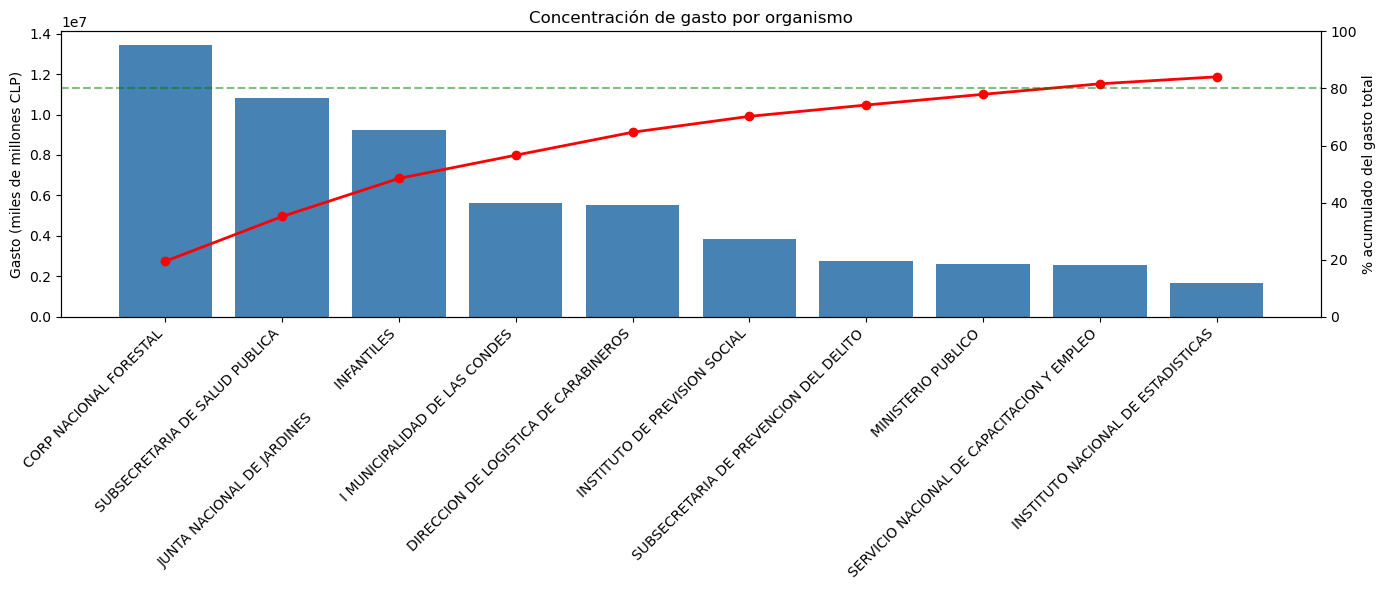

Imagen guardada en: C:\Users\OAD\Documents\mercado-publico-eda\assets\concentración_de_gasto_por_organismo.png
El top 10 acumula 84.1% del gasto total


In [92]:
grafico_pareto(gasto_por_organismo['total_linea_neto'], 'Concentración de gasto por organismo', n=10)

**Hallazgos clave:**

- Regla del 80/20 (Principio de Pareto):
  Solo 10 organismos concentran el 84.1% del gasto total, mientras que el resto de las instituciones se reparte un porcentaje marginal.

- Dominio en la cúpula:
  Casi dos terceras partes del gasto (64.6%) son ejecutadas por apenas 5 organismos.

- Impacto individual:
  Un solo organismo (Corporación Nacional Forestal) abarca casi una quinta parte del total (19.5%).

**¿El estado gasta de forma fragmentada o consolidada?**


In [93]:
tamaño_ocs = df.groupby("id")[["total_linea_neto"]].sum()
print(tamaño_ocs["total_linea_neto"].describe().apply(formato_clp))

count              $400.302
mean            $172.576,1M
std          $28.097.021,7M
min                      $0
25%                $296.304
50%                $919.160
75%                   $3,1M
max      $10.716.907.441,4M
Name: total_linea_neto, dtype: object


**Hallazgos clave:**
- Fragmentación masiva a nivel transaccional:
    - Alto volumen de compras pequeñas: Se registran 400,300 transacciones.
    - Mediana muy baja ($919.16K): El 50% de las líneas de compra no supera el millón de pesos.
    - Rango intercuartil acotado: El 75% de las transacciones son por montos inferiores a $3.07M. La gestión cotidiana del Estado se compone de micro y pequeñas compras.

- Sesgo y asimetría extrema en los montos:
    - Distorsión del promedio: La media ($\approx \$172.58\text{B}$) es 187,000 veces mayor que la mediana ($\approx \$919.16\text{K}$). Esto ocurre cuando un puñado de compras de escala masiva distorsiona el comportamiento del total.
    - Volatilidad gigante: Una desviación estándar de $28.10T y un coeficiente de variación de 162.8 confirman la presencia de mega-operaciones atípicas (con un máximo de $10.72P).

    Conclusión: A nivel de gestión diaria y volumen de órdenes, el Estado opera de forma muy fragmentada (miles de transacciones pequeñas). Sin embargo, a nivel de presupuesto total, el gasto está altamente concentrado en un número mínimo de transacciones monumentales.


**¿Existe un monopolio o está abierto a la competencia?**


In [94]:
n_proveedores = df["nombre_proveedor"].nunique()
n_ocs = df["id"].nunique()

print(F"Proveedores unicos: {n_proveedores:,}")
print(f"OCs totales: {n_ocs:,}")
print("----------")
print(f"Ratio: {n_proveedores/n_ocs:.2f}")
print(f"OCs por proveedor {n_ocs/n_proveedores:.2f}")

Proveedores unicos: 35,769
OCs totales: 400,302
----------
Ratio: 0.09
OCs por proveedor 11.19


**Hallazgos clave:**

- Alta atomización de participantes:
    - Contar con 35,769 proveedores únicos en 400,302 órdenes de compra (OCs) descarta categóricamente una estructura monopolística. Hay un abanico amplio de competidores adjudicándose contratos.
- Frecuencia de adjudicación equilibrada:
    - El promedio de 11.19 OCs por proveedor indica que las órdenes no están hiperconcentradas en un solo jugador desde la perspectiva del volumen de transacciones.


    Advertencia metodológica:

Estas métricas evalúan la competencia en conteo de transacciones (OCs), no en monto monetario ($).

Un mercado puede tener miles de proveedores recibiendo órdenes pequeñas (aparentando alta competencia), mientras que un puñado de actores grandes (oligopolio) se adjudica el 80%+ del dinero. Para determinar si existe concentración de mercado real (p. ej., índice Herfindahl-Hirschman - HHI), se debe replicar este análisis ponderado por el monto total adjudicado por proveedor.

---

**¿Cúanto gasta el estado por región?**


In [95]:
gasto_por_region = df.groupby('region_de_compra')[['total_linea_neto']].sum().sort_values('total_linea_neto', ascending=False)
print(gasto_por_region.apply(lambda x: x.apply(formato_clp)))

                                                    total_linea_neto
region_de_compra                                                    
Región Metropolitana de Santiago                  $66.752.887.879,8M
Región del Biobío                                    $987.849.763,5M
Región de Valparaíso                                 $552.596.586,7M
Región de la Araucanía                               $257.652.374,1M
Región Aysén del General Carlos Ibáñez del Campo     $101.309.146,8M
Región de Coquimbo                                    $98.607.017,2M
Metropolitana                                         $66.642.965,4M
Región de Los Ríos                                    $60.689.833,0M
Región de Tarapacá                                    $43.024.574,3M
Región del Libertador General Bernardo O´Higgins      $36.198.659,8M
Región de Antofagasta                                 $31.578.932,3M
Región de los Lagos                                   $26.141.848,0M
Región del Maule                  

In [96]:
mapa_regiones = {
    # Metropolitana
    "Región Metropolitana de Santiago": "Región Metropolitana de Santiago",
    "Metropolitana": "Región Metropolitana de Santiago",
    # Valparaíso
    "Región de Valparaíso": "Región de Valparaíso",
    "Valparaíso": "Región de Valparaíso",
    # Biobío
    "Región del Biobío": "Región del Biobío",
    "Bío-Bío": "Región del Biobío",
    # Araucanía
    "Región de la Araucanía": "Región de la Araucanía",
    "Araucanía": "Región de la Araucanía",
    # Los Lagos
    "Región de los Lagos": "Región de Los Lagos",
    "Los Lagos": "Región de Los Lagos",
    # Maule
    "Región del Maule": "Región del Maule",
    "Maule": "Región del Maule",
    # O'Higgins
    "Región del Libertador General Bernardo O´Higgins": "Región del Libertador General Bernardo O'Higgins",
    "Lib. Gral. Bdo. O'Higgins": "Región del Libertador General Bernardo O'Higgins",
    # Los Ríos
    "Región de Los Ríos": "Región de Los Ríos",
    "Los Ríos": "Región de Los Ríos",
    # Aysén
    "Región Aysén del General Carlos Ibáñez del Campo": "Región de Aysén del General Carlos Ibáñez del Campo",
    "Aysén": "Región de Aysén del General Carlos Ibáñez del Campo",
    # Magallanes
    "Región de Magallanes y de la Antártica": "Región de Magallanes y de la Antártica Chilena",
    "Magallanes y Antártica": "Región de Magallanes y de la Antártica Chilena",
    # Coquimbo
    "Región de Coquimbo": "Región de Coquimbo",
    "Coquimbo": "Región de Coquimbo",
    # Antofagasta
    "Región de Antofagasta": "Región de Antofagasta",
    "Antofagasta": "Región de Antofagasta",
    # Atacama
    "Región de Atacama": "Región de Atacama",
    "Atacama": "Región de Atacama",
    # Tarapacá
    "Región de Tarapacá": "Región de Tarapacá",
    "Tarapacá": "Región de Tarapacá",
    # Ñuble
    "Región del Ñuble": "Región del Ñuble",
    "Ñuble": "Región del Ñuble",
    # Arica y Parinacota
    "Región de Arica y Parinacota": "Región de Arica y Parinacota",
    "Arica y Parinacota": "Región de Arica y Parinacota",
}

df['region_de_compra'] = df['region_de_compra'].replace(mapa_regiones)

print('Regiones únicas tras consolidar:', df['region_de_compra'].nunique()) #Comprobación

Regiones únicas tras consolidar: 25


In [97]:
df["region_de_compra"] = (df["region_de_compra"].str.strip())
df["region_de_compra"] = df["region_de_compra"].str.title()
df["region_de_compra"].unique()

array(['Región Del Maule', 'Región De La Araucanía', 'Región De Coquimbo',
       'Región Metropolitana De Santiago', 'Región De Los Ríos',
       'Región Del Biobío', 'Región De Valparaíso', 'Región De Los Lagos',
       'Región De Atacama',
       "Región Del Libertador General Bernardo O'Higgins",
       'Región De Antofagasta',
       'Región De Aysén Del General Carlos Ibáñez Del Campo',
       'Región De Arica Y Parinacota', 'Región De Tarapacá',
       'Región Del Ñuble',
       'Región De Magallanes Y De La Antártica Chilena'], dtype=object)

In [98]:
df["region_de_compra"].nunique()

16

In [99]:
gasto_por_region = df.groupby('region_de_compra')[['total_linea_neto']].sum().sort_values('total_linea_neto', ascending=False)
print(gasto_por_region.apply(lambda x: x.apply(formato_clp)))

                                                      total_linea_neto
region_de_compra                                                      
Región Metropolitana De Santiago                    $66.819.530.845,2M
Región Del Biobío                                      $987.892.599,3M
Región De Valparaíso                                   $556.263.150,4M
Región De La Araucanía                                 $261.066.960,8M
Región De Aysén Del General Carlos Ibáñez Del C...     $101.647.721,6M
Región De Coquimbo                                      $98.662.784,1M
Región De Los Ríos                                      $61.514.895,6M
Región De Tarapacá                                      $43.025.324,3M
Región Del Libertador General Bernardo O'Higgins        $37.265.962,2M
Región De Antofagasta                                   $31.613.782,8M
Región De Los Lagos                                     $27.918.417,8M
Región Del Maule                                        $18.781.064,4M
Región

In [100]:
#tops y pct
top_10_region = gasto_por_region.head(10)['total_linea_neto'].sum()
top_5_region = gasto_por_region.head(5)['total_linea_neto'].sum()
top_1_region = gasto_por_region.head(1)['total_linea_neto'].sum()


total_regiones = gasto_por_region['total_linea_neto'].sum()
relacion_porcentual_regiones_top10 = (top_10_region / total_regiones) * 100
relacion_porcentual_regiones_top5 = (top_5_region / total_regiones) * 100
relacion_porcentual_regiones_top1 = (top_1_region / total_regiones) * 100


print(f'El top 10 de regiones concentran el: {relacion_porcentual_regiones_top10}% del gasto')
print(f'El top 5 de regiones concentran el: {relacion_porcentual_regiones_top5}% del gasto')
print(f'El top 1 de regiones concentran el: {relacion_porcentual_regiones_top1}% del gasto')

El top 10 de regiones concentran el: 99.8782921460435% del gasto
El top 5 de regiones concentran el: 99.48444059017541% del gasto
El top 1 de regiones concentran el: 96.72416310309336% del gasto


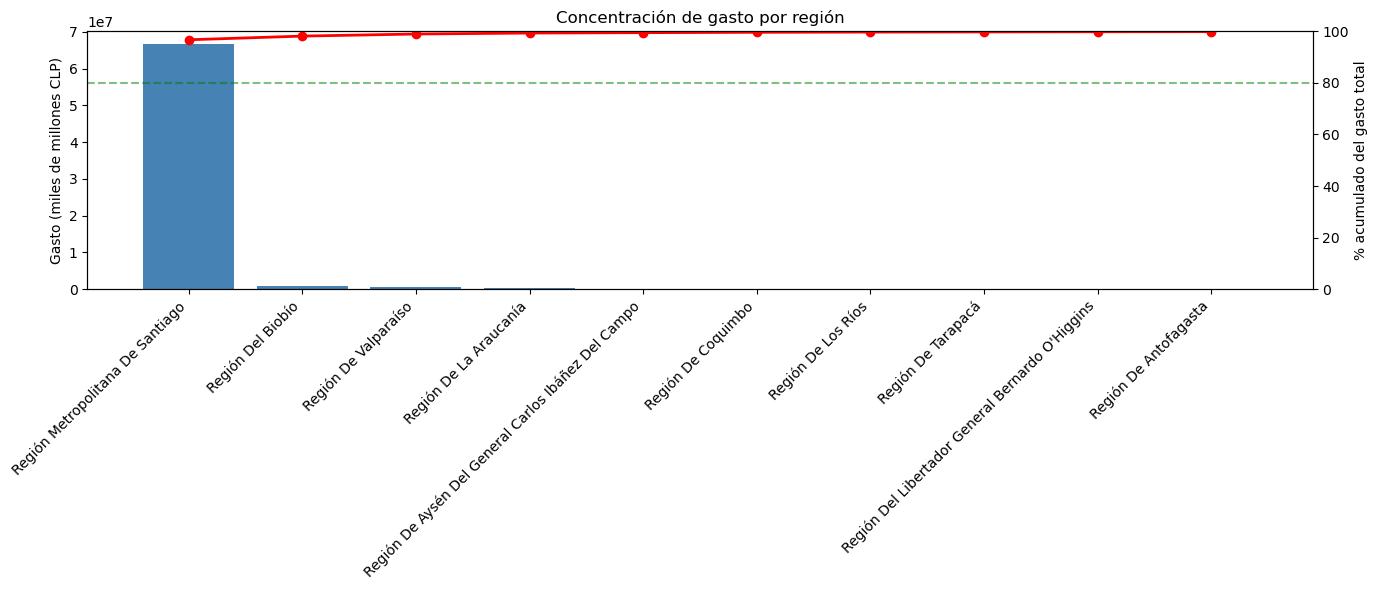

Imagen guardada en: C:\Users\OAD\Documents\mercado-publico-eda\assets\concentración_de_gasto_por_región.png
El top 10 acumula 99.9% del gasto total


In [101]:
grafico_pareto(gasto_por_region['total_linea_neto'], 'Concentración de gasto por región')

**Hallazgos clave:**
- Macro-centralismo absoluto (Top 1 = 96.7%):
    - La Región Metropolitana de Santiago absorbe por sí sola el 96.7% del gasto total (~66.82 Peta-pesos CLP). Casi la totalidad del presupuesto ejecutado queda registrado en la capital.
- Marginalidad regional acumulada (Resto de Chile = 3.3%):
    - Las otras 15 regiones juntas representan apenas el 3.3% del dinero gastado.
    - Incluso las regiones que siguen en el ranking (Biobío con ~987.89T y Valparaíso con ~556.26T) quedan opacadas en el gráfico por la diferencia de escala de Santiago.
- Concentración técnica en el Top 5 (99.5%):
    - Las primeras 5 regiones en el listado abarcan el 99.5% del presupuesto regionalizado.


Interpretación en Ciencia de Datos:

Más que reflejar un "no gasto" en regiones, este patrón suele indicar un sesgo de facturación centralizada (ej. casas matrices de proveedores o ministerios con domicilio fiscal en Santiago registrando las compras que benefician a todo el país).

**¿Cúanto gasta el estado por rubro?**


In [102]:
gasto_por_rubro = df.groupby('rubro')[['total_linea_neto']].sum().sort_values('total_linea_neto', ascending=False)
print(gasto_por_rubro.apply(lambda x: x.apply(formato_clp)))

                                                      total_linea_neto
rubro                                                                 
Tecnologías de la información, telecomunicacion...  $29.445.644.024,9M
Servicios de transporte, almacenaje y correo        $13.189.181.980,2M
Servicios basados en ingeniería, ciencias socia...  $11.859.603.586,4M
Servicios básicos y de información pública           $5.542.473.373,6M
Servicios financieros, pensiones y seguros           $4.362.020.802,1M
Equipos y suministros de defensa, orden público...     $951.040.669,7M
Servicios de construcción y mantenimiento              $836.635.518,4M
Vehículos y equipamiento en general                    $715.161.102,0M
Obras MINVU                                            $525.265.460,2M
Servicios de limpieza industrial                       $426.771.391,7M
Maquinaria para minería y perforación                  $309.621.608,8M
Servicios profesionales, administrativos y cons...     $301.386.503,4M
Artícu

In [103]:
#tops y pct
top_10_rubros = gasto_por_rubro.head(10)['total_linea_neto'].sum()
top_5_rubros = gasto_por_rubro.head(5)['total_linea_neto'].sum()
top_1_rubros = gasto_por_rubro.head(1)['total_linea_neto'].sum()


total_regiones = gasto_por_rubro['total_linea_neto'].sum()
relacion_porcentual_rubros_top10 = (top_10_rubros / total_regiones) * 100
relacion_porcentual_rubros_top5 = (top_5_rubros / total_regiones) * 100
relacion_porcentual_rubros_top1 = (top_1_rubros / total_regiones) * 100


print(f'El top 10 de rubros concentran el: {relacion_porcentual_rubros_top10}% del gasto')
print(f'El top 5 de rubros concentran el: {relacion_porcentual_rubros_top5}% del gasto')
print(f'El top 1 de rubros concentran el: {relacion_porcentual_rubros_top1}% del gasto')

El top 10 de rubros concentran el: 98.69130110021955% del gasto
El top 5 de rubros concentran el: 93.66629093533724% del gasto
El top 1 de rubros concentran el: 42.82780050769272% del gasto


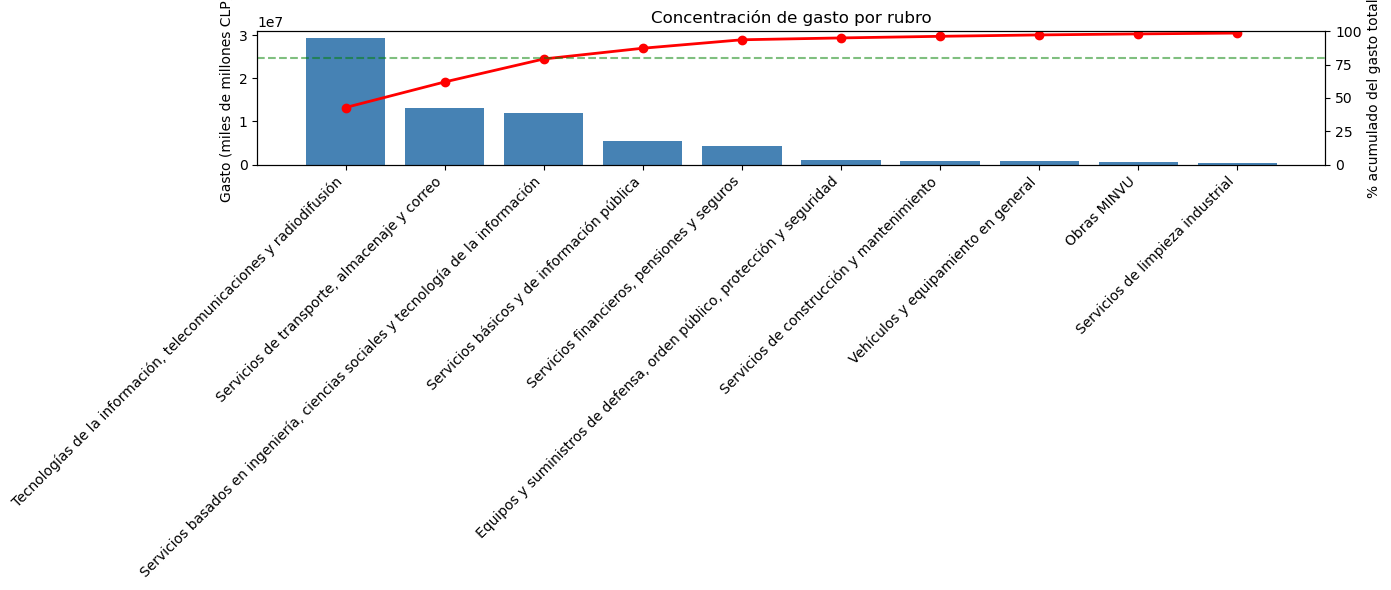

Imagen guardada en: C:\Users\OAD\Documents\mercado-publico-eda\assets\concentración_de_gasto_por_rubro.png
El top 10 acumula 98.7% del gasto total


In [104]:
grafico_pareto(gasto_por_rubro['total_linea_neto'], 'Concentración de gasto por rubro')

**Hallazgos clave:**
- Liderazgo absoluto de TI (Top 1 = 42.8%):
    - El rubro Tecnologías de la información, telecomunicaciones y radiodifusión absorbe por sí solo más de 4 de cada 10 pesos del Estado (42.8% / ~29.45 Peta-pesos CLP).
- Hiperconcentración en el Top 5 (93.7%):
    - Más del 93% del presupuesto en rubros se liquida en apenas 5 sectores principales: Tecnología, Transporte, Ingeniería/Ciencias Sociales, Servicios Básicos y Financieros/Seguros.
- Monopolización del Top 10 (98.7%):
    - Los primeros 10 rubros concentran el 98.7% del gasto total.
    - Efecto cola larga: Los otros 34 rubros restantes (que abarcan desde Salud, Educación y Alimentos hasta Medicamentos) deben repartirse apenas un marginal 1.3% del presupuesto registrado en estas órdenes.

**¿Cúanto gasta el estado por categoría?**


In [105]:
gasto_por_categoria = df.groupby("categoria")[["total_linea_neto"]].sum().sort_values("total_linea_neto", ascending=False)
print(gasto_por_categoria.apply(lambda x: x.apply(formato_clp)).head(15))

                                                      total_linea_neto
categoria                                                             
Servicios de transporte, almacenaje y correo / ...  $13.168.554.526,0M
Tecnologías de la información, telecomunicacion...  $12.309.857.475,4M
Servicios basados en ingeniería, ciencias socia...  $10.758.132.213,0M
Tecnologías de la información, telecomunicacion...   $9.582.304.136,8M
Tecnologías de la información, telecomunicacion...   $5.518.895.190,1M
Servicios básicos y de información pública / Se...   $5.361.071.587,0M
Servicios financieros, pensiones y seguros / Ba...   $3.785.869.481,4M
Tecnologías de la información, telecomunicacion...   $1.617.411.315,8M
Equipos y suministros de defensa, orden público...     $624.583.409,3M
Servicios de construcción y mantenimiento / Con...     $593.292.482,3M
Servicios financieros, pensiones y seguros / Se...     $540.469.243,4M
Consultoria / Consultoria / Planificación y Fac...     $525.285.937,9M
Vehícu

In [106]:
#tops y pct
top_10_gasto_categoria = gasto_por_categoria.head(10)['total_linea_neto'].sum()
top_5_gasto_categoria = gasto_por_categoria.head(5)['total_linea_neto'].sum()
top_1_gasto_categoria = gasto_por_categoria.head(1)['total_linea_neto'].sum()

total_gasto_categoria = gasto_por_categoria['total_linea_neto'].sum()
relacion_porcentual_categorias_top10 = (top_10_gasto_categoria / total_gasto_categoria) * 100
relacion_porcentual_categorias_top5 = (top_5_gasto_categoria / total_gasto_categoria) * 100
relacion_porcentual_categorias_top1 = (top_1_gasto_categoria / total_gasto_categoria) * 100

print(f'El top 10 de categorias concentran el: {relacion_porcentual_categorias_top10}% del gasto')
print(f'El top 5 de categorias concentran el: {relacion_porcentual_categorias_top5}% del gasto')
print(f'El top 1 de categorias concentran el: {relacion_porcentual_categorias_top1}% del gasto')

El top 10 de categorias concentran el: 92.09698788874098% del gasto
El top 5 de categorias concentran el: 74.66919850840404% del gasto
El top 1 de categorias concentran el: 19.153265105614786% del gasto


C:\Users\OAD\AppData\Local\Temp\ipykernel_8836\2670859675.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


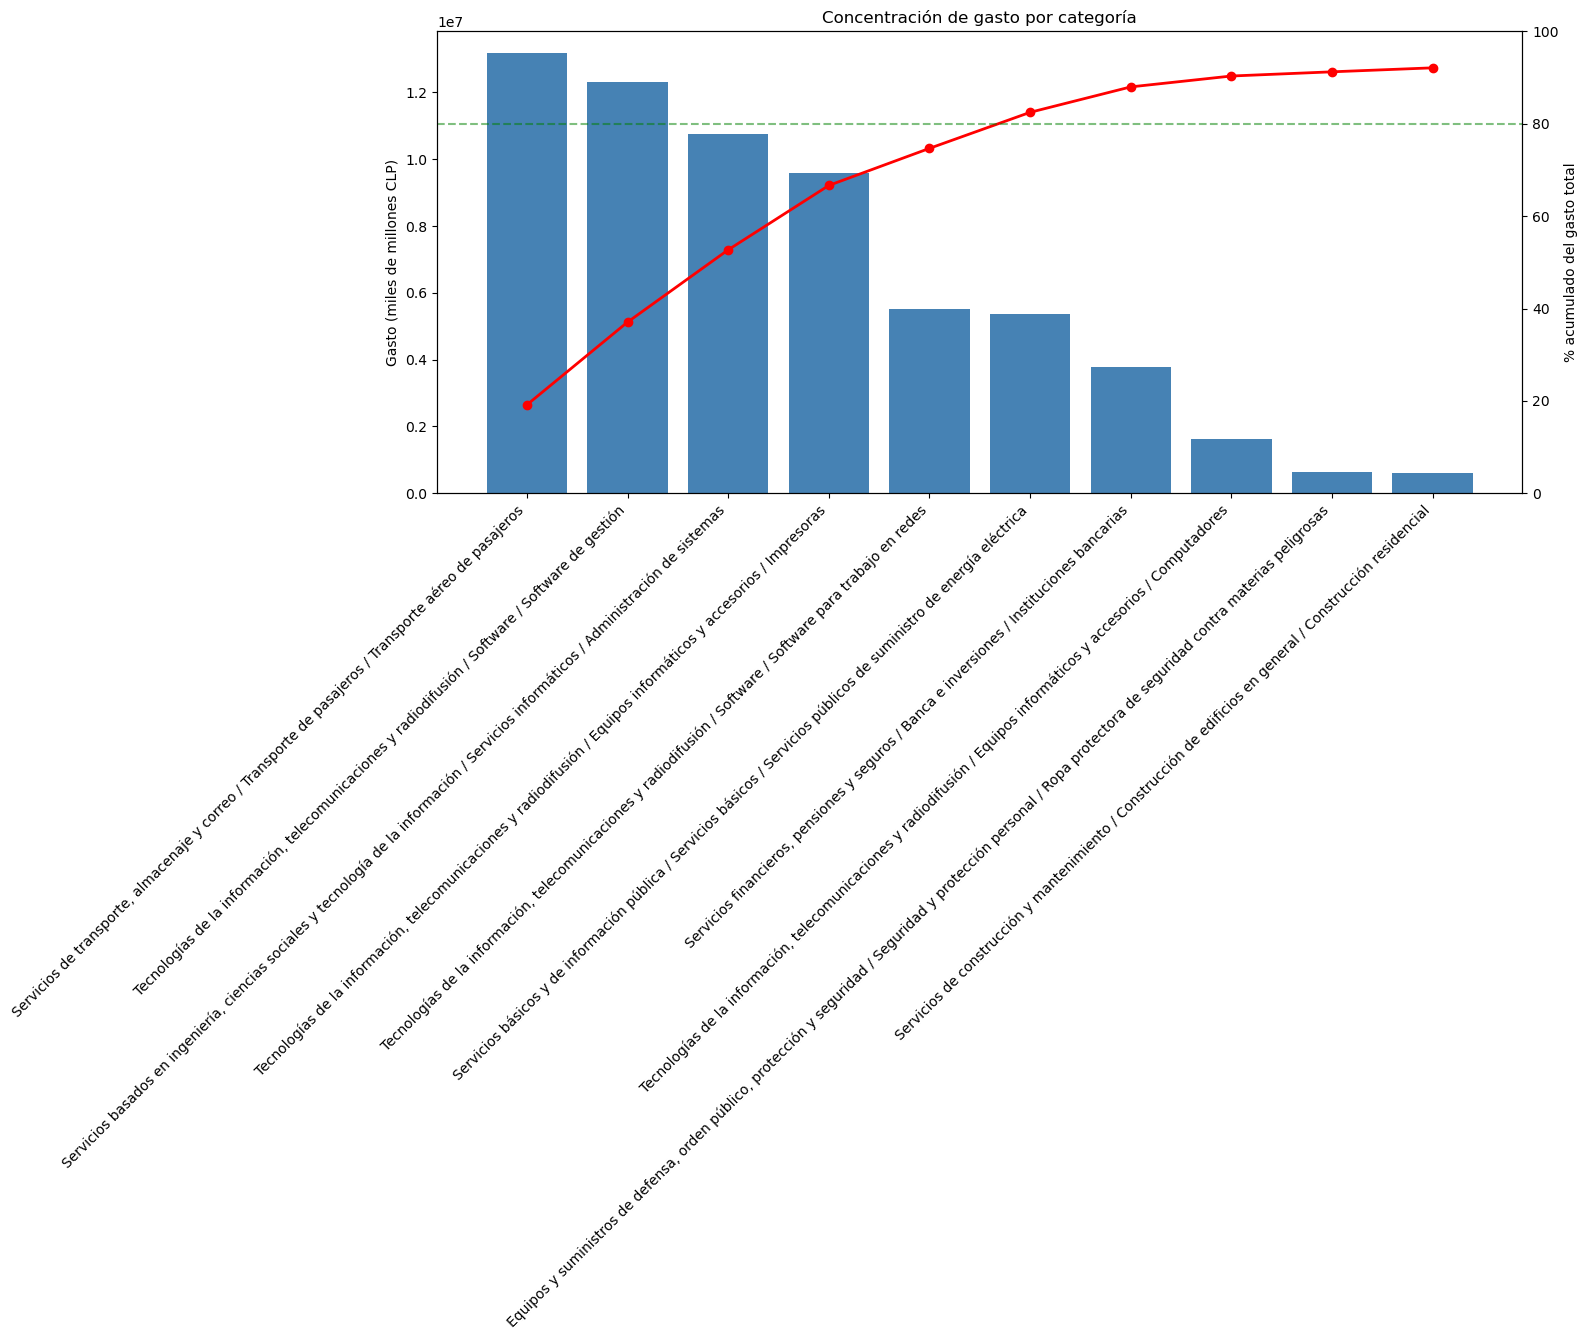

Imagen guardada en: C:\Users\OAD\Documents\mercado-publico-eda\assets\concentración_de_gasto_por_categoría.png
El top 10 acumula 92.1% del gasto total


In [107]:
grafico_pareto(gasto_por_categoria["total_linea_neto"], "Concentración de gasto por categoría")

**Hallazgos clave:**
- Dominio masivo del Top 10 (92.1%):
    - Casi la totalidad del presupuesto asignado a categorías se agrupa en solo 10 rubros. Todo el resto de las categorías representa un marginal 7.9%.
- Núcleo del gasto público (Top 5 = 74.7%):
    - Tres de cada cuatro pesos se destinan a las 5 categorías principales.
    - Categoría líder: Servicios de transporte, almacenaje y correo (Transporte aéreo de pasajeros) abarca por sí sola el 19.2% del gasto total (~13.17 Peta-pesos CLP).
- Prevalencia del sector TI y Servicios:
    - Múltiples subcategorías de Tecnologías de la Información (software de gestión, administración de sistemas, equipos impresoras) dominan el Top 5, convirtiendo a la transformación digital y el soporte informático en uno de los mayores motores del gasto estatal.

    Conclusión: El gasto no es homogéneo entre sectores. Existe una fuerte dependencia presupuestaria en infraestructura de transporte, tecnología (TI) e ingeniería/consultoría.

---

**¿Qué organismos tienen pocos proveedores y que se supone es más facil entrar?**


In [108]:
organismos_n_proveedores_unicos = df.groupby("organismo_publico")["nombre_proveedor"].nunique().sort_values(ascending=False)

In [109]:
organismos_n_proveedores_unicos.tail(10)

organismo_publico
ASOCIACION DE MUNICIPALIDADES DE LA REGION DE COQUIMBO                   1
CORPORACIÓN MUNICIPAL DE DESARROLLO SOCIAL DE LOS MUERMOS                1
SERVICIO NACIONAL DE MENORES                                             1
TRIBUNAL ELECTORAL REGIONAL SEPTIMA REGI                                 1
FUNDACION DE CULTURA, TURISMO Y DEPORTES DE LA MUNICIPALIDAD DE MARIA    1
ASOCIACION DE MUNICIPALIDADES NAHUELBUTA                                 1
Corporación de Cultura Isla de Maipo                                     1
ASOCIACIÓN DE MUNICIPALIDADES CORDILLERANAS DE LA ARAUCANÍA              1
CORP MUNICIPAL DE SERVICIOS Y DESARROLLO                                 1
ACADEMIA NACIONAL DE ESTUDIOS POLITICOS Y ESTRATEGICOS                   1
Name: nombre_proveedor, dtype: int64

In [110]:
organismos_n_proveedores_unicos_mayor_a_10 = organismos_n_proveedores_unicos[organismos_n_proveedores_unicos >= 10]
organismos_n_proveedores_unicos_mayor_a_10.tail(20)

organismo_publico
CORPORACION MUNICIPAL DE DEPORTE DE TALCA                                 11
SUBSECRETARIA DE TURISMO                                                  11
SUBSECRETARIA DEL PATRIMONIO CULTURAL                                     11
DELEGACIÓN PRESIDENCIAL PROVINCIAL DE MAIPO                               10
SERVICIO LOCAL DE EDUCACIÓN PÚBLICA ANTOFAGASTA                           10
CORPORACIÓN DESARROLLA BIOBÍO                                             10
DELEGACIÓN PRESIDENCIAL PROVINCIAL DE CHAÑARAL                            10
SERVICIO LOCAL DE EDUCACIÓN PÚBLICA TALAGANTE                             10
JUNTA DE AERONAUTICA CIVIL                                                10
ASOCIACION DE MUNICIPALIDADES BIO BIO CENTRO                              10
SERVICIO DE VIVIENDA Y URBANIZACION VI REGION                             10
Corporación Municipal de Cultura de San Clemente                          10
CORPORACION DE DESARROLLO DE MAGALLANES Y DE LA ANTARTICA 

**Hallazgos clave:**

Conclusión: Este filtro por sí solo resulta bastante ambiguo para tomar decisiones. Para que un hallazgo de "barrera de entrada" sea sólido, necesitarías cruzar: Cantidad de OCs / N° de proveedores / Monto promedio de compra.

**¿Qué categorías y rubros tienen mucho gasto y tambien tienen pocos proveedores?**


In [111]:
df_analisis = df.groupby("categoria").agg({
    "nombre_proveedor": "nunique",
    "total_linea_neto": "sum"
})
df_analisis.head(10)

,nombre_proveedor,total_linea_neto
categoria,,
"Alimentos, bebidas y tabaco / Aceites y grasas comestibles / Aceites vegetales y grasas comestibles",172,2.037380e+08
"Alimentos, bebidas y tabaco / Aceites y grasas comestibles / Grasas y aceites animales comestibles",59,2.601253e+07
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Acompañamientos preparados",198,3.591597e+08
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Bebidas y comidas infantiles",63,9.656538e+07
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Empanadas, tartas y pies",148,1.339176e+08
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Ensaladas preparadas",22,2.165560e+06
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Jaleas, gelatinas, mermeladas, pastas de untar, dulces y conservas de frutas",197,1.214951e+08
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Materiales y mezclas instantáneas",83,1.310093e+08
"Alimentos, bebidas y tabaco / Alimentos preparados y conservados / Pasta o tallarines naturales",116,8.254283e+08


In [112]:
df_analisis.columns = ['proveedores', 'gasto'] #Columnas

resultado_analisis = df_analisis[
    (df_analisis['gasto'] >= df_analisis['gasto'].quantile(0.8)) & #Gasto mayor que el 80%
    (df_analisis['proveedores'] <= df_analisis['proveedores'].quantile(0.25)) #Proveedores menores que 25%
].sort_values('gasto', ascending=False)

resultado_analisis['gasto'] = resultado_analisis['gasto'].apply(formato_clp)
print(resultado_analisis)

                                                    proveedores  \
categoria                                                         
Servicios financieros, pensiones y seguros / Ba...            6   
Maquinaria para minería y perforación / Equipo ...            2   
Instrumentos musicales, juegos, juguetes, artes...            6   
Equipamiento para laboratorios / Equipos e insu...            7   
Maquinaria para minería y perforación / Artícul...            2   
Equipamiento para laboratorios / Instrumentos d...            6   
Servicios financieros, pensiones y seguros / Ba...            4   
Maquinaria para agricultura, pesca y silvicultu...            4   
Vehículos y equipamiento en general / Component...            5   
Maquinaria para minería y perforación / Maquina...            3   
Servicios de perforación de minería, petróleo y...            6   
Maquinaria para minería y perforación / Maquina...            4   
Servicios profesionales, administrativos y cons...            

| categoria                                                                                                                                                                                                   |   proveedores | gasto   |
|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------:|:--------|
| Servicios financieros, pensiones y seguros / Banca e inversiones / Instituciones bancarias                                                                                                                  |             6 | 3,79P   |
| Maquinaria para minería y perforación / Equipo para perforación y exploración para petróleo / Equipo de perforación direccional                                                                             |             2 | 3,45T   |
| Instrumentos musicales, juegos, juguetes, artesanías y materiales educativos / Materiales, artículos y suministros didácticos profesionales y para el desarrollo personal / Recursos de lenguas extranjeras |             6 | 2,92T   |
| Equipamiento para laboratorios / Equipos e insumos para laboratorio / Bibliotecas técnicas y material relacionado                                                                                           |             7 | 1,60T   |
| Maquinaria para minería y perforación / Artículos para perforación de petróleo y gas / Lodo de perforación                                                                                                  |             2 | 1,00T   |
| Equipamiento para laboratorios / Instrumentos de medida y experimentación / Instrumentos geofísicos, geotécnicos e hidrológicos                                                                             |             6 | 320,09B |
| Servicios financieros, pensiones y seguros / Banca e inversiones / Asesorías de inversiones                                                                                                                 |             4 | 218,43B |
| Maquinaria para agricultura, pesca y silvicultura / Maquinaria para agricultura, silvicultura y paisaje / Equipamiento para aves de corral y ganado                                                         |             4 | 122,00B |
| Vehículos y equipamiento en general / Componentes para sistemas aeroespaciales / Sistemas de comunicaciones en vuelo                                                                                        |             5 | 93,11B  |
| Maquinaria para minería y perforación / Maquinaria para minería / Barrenas para rocas                                                                                                                       |             3 | 77,40B  |
| Servicios de perforación de minería, petróleo y gas / Servicios gestión y proceso de datos e información sobre petróleo y gas / Servicios de interpretación y traducción del campo petrolífero              |             6 | 49,27B  |
| Maquinaria para minería y perforación / Maquinaria para minería / Equipo de corte                                                                                                                           |             4 | 37,64B  |
| Servicios profesionales, administrativos y consultorías de gestión empresarial / Servicios legales / Derecho penal                                                                                          |             5 | 25,84B  |
| Servicios basados en ingeniería, ciencias sociales y tecnología de la información / Servicios informáticos / Programadores informáticos                                                                     |             4 | 25,16B  |
| Artículos para plantas y animales / Alimento para animales / Alimento para roedores                                                                                                                         |             3 | 21,50B  |
| Servicios básicos y de información pública / Telecomunicaciones / Capacidades del eje troncal de telecomunicaciones                                                                                         |             4 | 11,04B  |
| Equipamiento y suministros médicos / Productos para imágenes y de medicina nuclear / Artículos del acelerador lineal de terapia de radiación de intensidad modulada (IMRT) l                                |             4 | 8,21B   |
| Servicios financieros, pensiones y seguros / Banca e inversiones / Servicios de transferencia de fondos, compensación y cambio                                                                              |             3 | 7,20B   |
| Servicios de defensa nacional, orden público y seguridad / Orden público y seguridad / Sistema judicial                                                                                                     |             5 | 5,84B   |
| Servicios agrícolas, pesqueros, forestales y relacionados con la fauna / Cultivos forestales / Servicios de conservación forestal                                                                           |             7 | 4,57B   |
| Servicios financieros, pensiones y seguros / Contabilidad y auditorías / Asesoría tributarias                                                                                                               |             7 | 3,68B   |
| Servicios de perforación de minería, petróleo y gas / Servicios gestión y proceso de datos e información sobre petróleo y gas / Servicios de comunicación de datos del campo petrolífero                    |             1 | 2,98B   |

In [113]:
df_analisis_2 = df.groupby("rubro").agg({
    "nombre_proveedor": "nunique",
    "total_linea_neto": "sum"
})
df_analisis_2.head(10)

,nombre_proveedor,total_linea_neto
rubro,,
"Alimentos, bebidas y tabaco",1989,2.031381e+12
Artículos de electrónica,523,7.066215e+08
Artículos de fabricación y producción,2426,3.650368e+10
Artículos eléctricos y de iluminación,1741,4.265524e+13
"Artículos para estructuras, obras y construcciones",3399,7.592943e+13
Artículos para plantas y animales,919,2.744141e+10
"Combustibles, lubricantes y anticorrosivos",908,1.509243e+13
Consultoria,24,1.490139e+09
"Educación, formación, entrenamiento y capacitación",772,1.841553e+11


In [114]:
df_analisis_2.columns = ["proveedores", "gasto"]

df_analisis_2 = df_analisis_2[
    (df_analisis_2["gasto"] >= df_analisis_2["gasto"].quantile(0.1)) & #gasto mayor al 10% del gasto total
    (df_analisis_2["proveedores"] <= df_analisis_2["proveedores"].quantile(0.1)) #proveedores menores al 10% de proveedores totales
].sort_values("gasto", ascending=False)

df_analisis_2["gasto"] = df_analisis_2["gasto"].apply(formato_clp)
print(df_analisis_2)

                                                    proveedores  \
rubro                                                             
Obras MINVU                                                  33   
Servicios medioambientales                                  167   
Servicios de perforación de minería, petróleo y...          225   
Obras                                                        27   

                                                              gasto  
rubro                                                                
Obras MINVU                                         $525.265.460,2M  
Servicios medioambientales                            $3.001.173,6M  
Servicios de perforación de minería, petróleo y...       $55.395,3M  
Obras                                                    $19.606,7M  


| rubro                                               |   proveedores | gasto   |
|:----------------------------------------------------|--------------:|:--------|
| Obras MINVU                                         |            33 | 525,27T |
| Servicios medioambientales                          |           167 | 3,00T   |
| Servicios de perforación de minería, petróleo y gas |           225 | 55,40B  |
| Obras                                               |            27 | 19,61B  |

**Hallazgos en Categorías (Matriz $P_{80}$ de Gasto vs $P_{25}$ de Proveedores):**

Las categorías donde la concentración del gasto en pocos actores es crítica son:
- Servicios Financieros y Banca (Extremo):
    - Banca e inversiones: Gasto colosal ($3.79P) repartido en solo 6 proveedores.
- Minería y Maquinaria Pesada:
    - Equipos para minería: $3.45T con apenas 2 proveedores.
    - Artículos de minería: $1.00T concentrado también en 2 proveedores.
- Música, Arte y Entretenimiento:
    - Instrumentos musicales/juegos: $2.92T con solo 6 proveedores.
- Equipamiento Científico y Laboratorio:
    - Insumos de laboratorio: $1.60T gestionados por solo 7 proveedores.

**Hallazgos en Rubros (Matriz $P_{10}$ de Gasto vs $P_{10}$ de Proveedores):**
A nivel macro (rubro), el filtro ($Gasto \ge P_{10}$ y $Proveedores \le P_{10}$) aísla áreas donde el volumen es alto pero el parque de proveedores es llamativamente reducido:
- Obras MINVU (Criticidad Alta):
    - Acumula $525.27T ejecutados por tan solo 33 proveedores. Es el rubro de infraestructura urbana con mayor concentración por empresa.
- Servicios Medioambientales:
    - Representa $3.00T distribuidos en 167 proveedores (pocos para la escala del rubro).
- Perforación y Minería/Petróleo:
    - Genera $55.40B repartidos en 225 proveedores.

**Resumén de Análisis:**

| Nivel | Sector Crítico | Gasto | Proveedores | Diagnóstico |
| --------- | ------------- | ------- | -------- | -----------|
| Categoría | Banca e Instituciones Financieras | $3.79P | 6 | Monopolización / Oligopolio financiero |
| Categoría | Equipos de Minería y Perforación | $3.45T | 2 | Captura de mercado por nicho técnico |
| Rubro | Obras MINVU | $525.27T | 33 | Alta barrera de entrada en licitaciones públicas |

**¿Que nichos especificos no están saturados?**

In [115]:
df_nichos = (
    df.groupby("categoria")
    .agg(
        gasto_total=("total_linea_neto", "sum"),
        n_proveedores=("codigo_de_proveedor", "nunique"),
        volumen_ocs=("id", "nunique"),
    )
    .reset_index()
)

df_nichos["gasto_por_proveedor"] = (
    df_nichos["gasto_total"] / df_nichos["n_proveedores"]
)

df_nichos["ocs_por_proveedor"] = (
    df_nichos["volumen_ocs"] / df_nichos["n_proveedores"]
)

df_nichos.sort_values("gasto_por_proveedor", ascending=False).head(10)

,categoria,gasto_total,n_proveedores,volumen_ocs,gasto_por_proveedor,ocs_por_proveedor
1717,"Servicios financieros, pensiones y seguros / B...",3.785869e+15,6,11,6.309782e+14,1.833333
1688,"Servicios de transporte, almacenaje y correo /...",1.316855e+16,94,2101,1.400910e+14,22.351064
1520,Servicios básicos y de información pública / S...,5.361072e+15,81,131,6.618607e+13,1.617284
1810,"Tecnologías de la información, telecomunicacio...",5.518895e+15,106,177,5.206505e+13,1.669811
1038,Maquinaria para minería y perforación / Equipo...,2.969798e+14,8,10,3.712248e+13,1.250000
1497,"Servicios basados en ingeniería, ciencias soci...",1.075813e+16,325,620,3.310195e+13,1.907692
1802,"Tecnologías de la información, telecomunicacio...",1.230986e+16,429,2024,2.869431e+13,4.717949
1782,"Tecnologías de la información, telecomunicacio...",9.582304e+15,364,2565,2.632501e+13,7.046703
1858,Vehículos y equipamiento en general / Equipo d...,2.068935e+14,9,12,2.298816e+13,1.333333
1754,"Servicios profesionales, administrativos y con...",1.883883e+14,11,13,1.712621e+13,1.181818


In [116]:
umbral_gasto_prov = df_nichos["gasto_por_proveedor"].quantile(0.75)
umbral_min_ocs = 5

nichos_oportunidad = df_nichos[
    (df_nichos["gasto_por_proveedor"] >= umbral_gasto_prov)
    & (df_nichos["volumen_ocs"] >= umbral_min_ocs)
].sort_values("gasto_por_proveedor", ascending=False)

nichos_oportunidad[
    ["categoria", "n_proveedores", "volumen_ocs", "gasto_por_proveedor"]
].head(10)

,categoria,n_proveedores,volumen_ocs,gasto_por_proveedor
1717,"Servicios financieros, pensiones y seguros / B...",6,11,6.309782e+14
1688,"Servicios de transporte, almacenaje y correo /...",94,2101,1.400910e+14
1520,Servicios básicos y de información pública / S...,81,131,6.618607e+13
1810,"Tecnologías de la información, telecomunicacio...",106,177,5.206505e+13
1038,Maquinaria para minería y perforación / Equipo...,8,10,3.712248e+13
1497,"Servicios basados en ingeniería, ciencias soci...",325,620,3.310195e+13
1802,"Tecnologías de la información, telecomunicacio...",429,2024,2.869431e+13
1782,"Tecnologías de la información, telecomunicacio...",364,2565,2.632501e+13
1858,Vehículos y equipamiento en general / Equipo d...,9,12,2.298816e+13
1754,"Servicios profesionales, administrativos y con...",11,13,1.712621e+13


In [117]:
import numpy as np

condiciones = [
    (df_nichos["ocs_por_proveedor"] > 5),
    (df_nichos["n_proveedores"] <= 15) & (df_nichos["ocs_por_proveedor"] <= 5),
]

elecciones = ["Abierto / Dinámico", "Cerrado / Concentrado"]

df_nichos["tipo_de_mercado"] = np.select(
    condiciones, elecciones, default="Competido / Moderado"
)

df_nichos["gasto_por_proveedor_fmt"] = df_nichos["gasto_por_proveedor"].apply(
    formato_clp
)

columnas_mostrar = [
    "categoria",
    "tipo_de_mercado",
    "n_proveedores",
    "volumen_ocs",
    "gasto_por_proveedor_fmt",
]

df_nichos.sort_values("gasto_por_proveedor", ascending=False)[
    columnas_mostrar
].head(10)

,categoria,tipo_de_mercado,n_proveedores,volumen_ocs,gasto_por_proveedor_fmt
1717,"Servicios financieros, pensiones y seguros / B...",Cerrado / Concentrado,6,11,"$630.978.246,9M"
1688,"Servicios de transporte, almacenaje y correo /...",Abierto / Dinámico,94,2101,"$140.091.005,6M"
1520,Servicios básicos y de información pública / S...,Competido / Moderado,81,131,"$66.186.069,0M"
1810,"Tecnologías de la información, telecomunicacio...",Competido / Moderado,106,177,"$52.065.049,0M"
1038,Maquinaria para minería y perforación / Equipo...,Cerrado / Concentrado,8,10,"$37.122.475,9M"
1497,"Servicios basados en ingeniería, ciencias soci...",Competido / Moderado,325,620,"$33.101.945,3M"
1802,"Tecnologías de la información, telecomunicacio...",Competido / Moderado,429,2024,"$28.694.306,5M"
1782,"Tecnologías de la información, telecomunicacio...",Abierto / Dinámico,364,2565,"$26.325.011,4M"
1858,Vehículos y equipamiento en general / Equipo d...,Cerrado / Concentrado,9,12,"$22.988.161,5M"
1754,"Servicios profesionales, administrativos y con...",Cerrado / Concentrado,11,13,"$17.126.212,1M"


**Hallazgos clave:**

1.-**Los Nichos Reales "No Saturados" (Oportunidad Alta)**

Son sectores donde hay **alto presupuesto disponible**, una cantidad de proveedores moderada (no masificada) y un **alto volumen de Transacciones (OCs)**, lo que indica movilidad y oportunidades reales para nuevos oferentes:

- **Servicios de Transporte, Almacenaje y Correo:**
    - **Gasto/Proveedor:** $140,09T
    - **Rotación:** 2.101 OCs distribuidas en 94 proveedores (~22,3 OCs por proveedor).
    - **Diagnóstico:** Mercado **Abierto / Dinámico**. Es el nicho con mejor balance entre liquidez y flujo continuo de licitaciones.
- **Tecnologías de la Información y Telecomunicaciones (Subsector C - 1782):**
    - **Gasto/Proveedor:** $26,33T
    - **Rotación:** 2.565 OCs entre 364 proveedores (~7,0 OCs por proveedor).
    - **Diagnóstico:** Mercado **Abierto / Dinámico**. Alta demanda recurrente con espacio para la entrada de nuevos competidores.
- **Tecnologías de la Información y Telecomunicaciones (Subsector B - 1802):**
    - **Gasto/Proveedor:** $28,69T
    - **Rotación:** 2.024 OCs entre 429 proveedores (~4,7 OCs por proveedor).
    - **Diagnóstico:** Mercado **Competido pero Accesible**. Mantiene un retorno por empresa muy elevado con alta tasa de adjudicación.

2.-**Los Falsos Nichos "No Saturados" (Mercados Cerrados)**

Aparecen en los primeros lugares por tener un ratio $Gasto/Proveedor$ astronómico, pero **no representan mercados no saturados**, sino **oligopolios o nichos hiperconcentrados** con barreras de entrada extremas:

- **Servicios Financieros, Pensiones y Seguros:** $630,98T/proveedor con solo 6 empresas y 11 OCs (capturado por la banca).
- **Maquinaria para Minería y Perforación:** $37,12T/proveedor con 8 empresas y 10 OCs (nicho de alta especialización técnica).
- **Vehículos y Equipamiento / Servicios Profesionales:** Con 9 y 11 proveedores respectivamente y apenas ~1 OC por proveedor (contratos grandes aislados).

## Resumen Ejecutivo

| Categoría Especifica | Tipo de Mercado | Proveedores | Volumen OCs | Gasto / Proveedor | Diagnóstico |
| --- | --- | --- | --- | --- | --- |
| **Transporte, Almacenaje y Correo** | **Abierto / Dinámico** | 94 | 2.101 | **$140,09T** | 🟢 **Nicho #1:** Alta frecuencia y altísimo retorno. |
| **TI y Telecomunicaciones (1782)** | **Abierto / Dinámico** | 364 | 2.565 | **$26,33T** | 🟢 **Nicho #2:** Mayor flujo transaccional del Estado. |
| **TI y Telecomunicaciones (1802)** | **Competido / Moderado** | 429 | 2.024 | **$28,69T** | 🟢 **Nicho #3:** Alta liquidez acumulada. |
| **Servicios Financieros / Banca** | **Cerrado / Concentrado** | 6 | 11 | **$630,98T** | 🔴 **Falso Nicho:** Barrera de entrada institucional. |
| **Maquinaria Minería** | **Cerrado / Concentrado** | 8 | 10 | **$37,12T** | 🔴 **Falso Nicho:** Exclusividad técnica/proveedor único. |

---

# Export # 

In [118]:
df.to_parquet('C:/Users/OAD/Documents/mercado-publico-eda/data/processed/mercado_publico_eda_analyzed.parquet', index=False) 

In [119]:
import json


def exportar_markdowns(notebook_path, output_md_path):
    # Leer el archivo .ipynb
    with open(notebook_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    # Filtrar solo celdas de tipo 'markdown'
    markdowns = []
    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "markdown":
            # Unir las líneas de texto de la celda
            content = "".join(cell.get("source", []))
            markdowns.append(content)

    # Guardar en el archivo .md de salida
    with open(output_md_path, "w", encoding="utf-8") as f:
        f.write("\n\n---\n\n".join(markdowns))

    print(
        f"Exportación completada: {len(markdowns)} celdas guardadas en {output_md_path}"
    )


# Uso (reemplaza por el nombre de tu notebook):
exportar_markdowns("C:/Users/OAD/Documents/mercado-publico-eda/notebooks/02_analyze_mercado_publico_eda.ipynb", "C:/Users/OAD/Documents/mercado-publico-eda/reports/executive_summary.md")

Exportación completada: 32 celdas guardadas en C:/Users/OAD/Documents/mercado-publico-eda/reports/executive_summary.md


---